In [4]:
pip install pandas pyarrow

Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd

train = pd.read_parquet("../data/train_115-00000-of-00001.parquet")

val1 = pd.read_parquet("../data/validation-00000-of-00002.parquet")
val2 = pd.read_parquet("../data/validation-00001-of-00002.parquet")

validation = pd.concat([val1, val2], ignore_index=True)

dataset = pd.concat([train, validation], ignore_index=True)

print(dataset.shape)

(2148, 26)


In [12]:
print(dataset.columns.tolist())

['id', 'locale', 'partition', 'scenario', 'scenario_str', 'intent_idx', 'intent_str', 'utt', 'annot_utt', 'worker_id', 'slot_method', 'judgments', 'tokens', 'labels', 'audio', 'path', 'is_transcript_reported', 'is_validated', 'speaker_id', 'speaker_sex', 'speaker_age', 'speaker_ethnicity_simple', 'speaker_country_of_birth', 'speaker_country_of_residence', 'speaker_nationality', 'speaker_first_language']


In [13]:
print(dataset.dtypes)

id                              object
locale                          object
partition                       object
scenario                         int64
scenario_str                    object
intent_idx                       int64
intent_str                      object
utt                             object
annot_utt                       object
worker_id                       object
slot_method                     object
judgments                       object
tokens                          object
labels                          object
audio                           object
path                            object
is_transcript_reported            bool
is_validated                      bool
speaker_id                      object
speaker_sex                     object
speaker_age                     object
speaker_ethnicity_simple        object
speaker_country_of_birth        object
speaker_country_of_residence    object
speaker_nationality             object
speaker_first_language   

In [7]:
print(dataset.head())

      id locale partition  scenario    scenario_str  intent_idx  \
0   9702  vi-VN     train         3            play          20   
1   9671  vi-VN     train         3            play          20   
2  10249  vi-VN     train         3            play          51   
3   3854  vi-VN     train        10           audio          46   
4  12053  vi-VN     train         6  recommendation          55   

              intent_str                                                utt  \
0         play_audiobook     tôi muốn nghe một quyển sách bởi la quán trung   
1         play_audiobook  bắt đầu phát tam quốc diễn nghĩa ở chỗ mà tôi ...   
2              play_game                         hãy chơi một ván trivia   
3      audio_volume_mute                                   tắt loa làm ơn   
4  recommendation_movies  các bộ phim được đánh giá cao đang chiếu cuối ...   

                                           annot_utt worker_id  ...  \
0  tôi muốn nghe một quyển sách bởi [audiobook_au..

In [14]:
print("Số speaker:", dataset["speaker_id"].nunique())

print(dataset["speaker_id"].value_counts().describe())

Số speaker: 35
count     35.000000
mean      61.371429
std       38.924577
min        1.000000
25%       30.000000
50%       59.000000
75%       97.500000
max      151.000000
Name: count, dtype: float64


In [20]:
counts = dataset["speaker_id"].value_counts()

print(counts)

speaker_id
6552b16899091e4aaa587d1b    151
6537e43c008bb605430a302f    144
6557ebf8541bd32382739c1a    100
5c9d67af9e01ef000197cd15    100
5e133bbe6a5bff9911b73cfc    100
5ee49e71f8d19d00098aca3e     99
5fb84feecf0626000b30cbd3     99
5e4247e718b8910d4a2b9a34     99
604b93f6432ad99bcb4798e8     98
63cfbea470ab1bba9db30082     97
6573b7471b56f7fc59a7df63     96
63e534e8ae837950bc60d88b     88
616ca5967d36f0000bd47b78     82
6549198eec431d4a6768a13e     69
652d516527ad747c966f5af4     68
6346ccfb37ed7169c9b634fc     65
5c76a2d39dd0fe0001d9dfe0     62
6393bb7fbbd2bb29f99e6c9b     59
6551b3e927c9931d057a19a1     56
60fcdd4360f55caf7828de7b     53
60d3432bc679834595ca8139     51
655022ac88df62f61f5b47a6     38
650b02ed6511bb3fbf5da880     30
5fa23c9b64b18a4067cc842e     30
60b0f68c2d6061d4fce96316     30
646fec4b0c1269c0b550130f     30
6125b9496ba8eb9bcd1f60f1     30
5e25be7c5514e680ef436338     20
5cf03d69b094d700013e4d54     20
657c8d982832af573ef2c039     20
65a242d84b379f4cebea1b21     

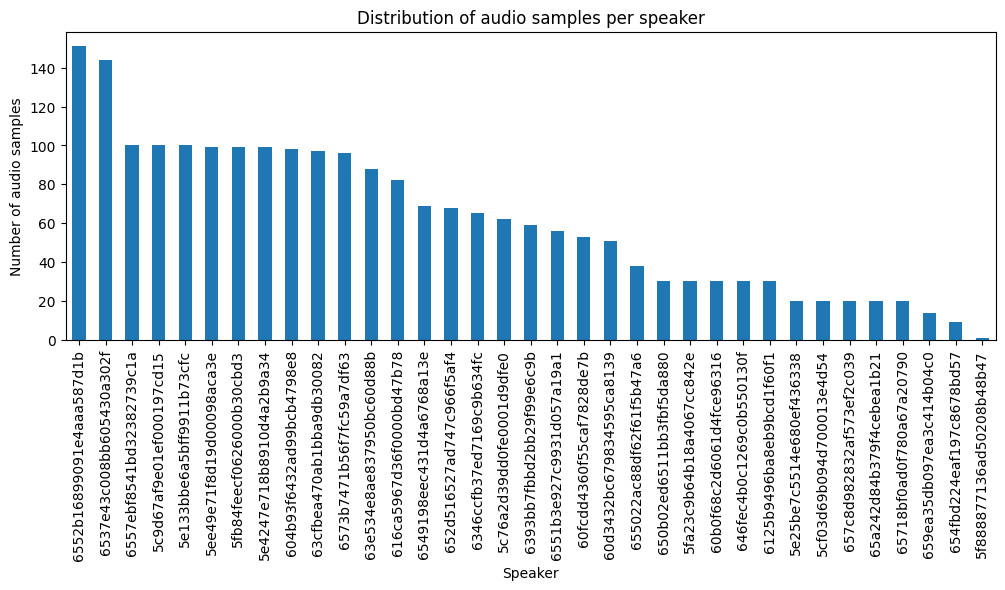

In [19]:
import matplotlib.pyplot as plt

counts = dataset["speaker_id"].value_counts()

plt.figure(figsize=(12,4))
counts.plot(kind="bar")
plt.ylabel("Number of audio samples")
plt.xlabel("Speaker")
plt.title("Distribution of audio samples per speaker")
plt.show()

In [23]:
print(type(dataset["audio"].iloc[0]))
print(dataset["audio"].iloc[0])

<class 'dict'>
{'bytes': b'RIFFF\xdb\x06\x00WAVEfmt \x10\x00\x00\x00\x01\x00\x01\x00\x80\xbb\x00\x00\x00w\x01\x00\x02\x00\x10\x00LIST\x1a\x00\x00\x00INFOISFT\x0e\x00\x00\x00Lavf57.83.100\x00data\x00\xdb\x06\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x

In [25]:
audio = dataset["audio"].iloc[0]

print(audio.keys())

dict_keys(['bytes', 'path'])


In [26]:
pip install soundfile

  Using cached pycparser-3.0-py3-none-any.whl.metadata (8.2 kB)
   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ------------------------------ --------- 0.8/1.0 MB 8.5 MB/s eta 0:00:01
   ---------------------------------------- 1.0/1.0 MB 8.2 MB/s  0:00:00
Using cached pycparser-3.0-py3-none-any.whl (48 kB)

   ------------- -------------------------- 1/3 [cffi]
   ------------- -------------------------- 1/3 [cffi]
   -------------------------- ------------- 2/3 [soundfile]
   ---------------------------------------- 3/3 [soundfile]

Note: you may need to restart the kernel to use updated packages.


In [27]:
import io
import soundfile as sf

audio = dataset["audio"].iloc[0]

waveform, sr = sf.read(io.BytesIO(audio["bytes"]))

duration = len(waveform) / sr

print(f"Sampling rate: {sr}")
print(f"Duration: {duration:.2f} seconds")

Sampling rate: 48000
Duration: 4.68 seconds


In [28]:
import io
import soundfile as sf
import numpy as np

durations = []

for audio in dataset["audio"]:
    waveform, sr = sf.read(io.BytesIO(audio["bytes"]))
    durations.append(len(waveform) / sr)

print(f"Min: {np.min(durations):.2f} s")
print(f"Mean: {np.mean(durations):.2f} s")
print(f"Median: {np.median(durations):.2f} s")
print(f"Max: {np.max(durations):.2f} s")

Min: 0.72 s
Mean: 3.71 s
Median: 3.36 s
Max: 15.96 s
